# Multiple Linear Regression: Predicting Household Income

This notebook addresses **Research Question 3**: Can a combination of regional and
household demographic factors reliably predict a household's income, and which variable
exerts the strongest determinant effect?

We build two OLS regression models:
- **Model 1:** Main effects only (region, education, occupation, class of worker, sex,
  marital status, age, family size, employed members)
- **Model 2:** Adds Region × Education interaction to test whether the education premium
  varies by region

We use **log-transformed income** as the dependent variable (validated in notebook 02).
Coefficients are interpreted as semi-elasticities: a one-unit change in the predictor
corresponds to approximately a 100×β% change in raw income.

**Sections:**
1. Imports & Configuration
2. Load Data
3. Feature Engineering
4. Model 1: Main Effects
5. Assumption Checking
6. Model 2: With Interaction
7. Standardized Coefficients
8. Robustness Checks
9. Visualizations
10. Key Findings

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from pathlib import Path

In [2]:
DATA_DIR = Path("../data/preprocessed")
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
INCOME_COL = "Log Total Household Income"
ALPHA = 0.05

## 2. Load Data

We load the preprocessed FIES dataset and keep only the columns needed for the
regression model. The outcome variable is `Log Total Household Income`; all other
columns serve as predictors.

In [3]:
df = pd.read_csv(DATA_DIR / "preprocessed-fies.csv")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded: 41,544 rows x 63 columns


## 3. Feature Engineering

The FIES dataset contains both categorical and numeric predictors. We need to encode
the categorical variables before fitting an OLS model.

**Encoding strategy:**
- **Region** (nominal): One-hot encoded, drop first to avoid dummy variable trap
- **Education** (ordinal): Mapped to 0–16 scale preserving natural ordering (vocational programs at college-equivalent level)
- **Occupation** (high cardinality): One-hot encode top 15 by frequency, collapse rest to "Other"
- **Class of Worker** (nominal): One-hot encoded
- **Sex, Marital Status** (binary): Single dummy variable each
- **Numeric predictors**: Used as-is (age, family size, employed members)

In [4]:
# Ordinal encoding for education — preserves the natural ordering
# Maps all 47 unique education values to a 0–16 ordinal scale
edu_map = {
    "No Grade Completed": 0,
    "Preschool": 0,
    "Grade 1": 1,
    "Grade 2": 2,
    "Grade 3": 3,
    "Grade 4": 4,
    "Grade 5": 5,
    "Grade 6": 6,
    "Elementary Graduate": 7,
    "First Year High School": 8,
    "Second Year High School": 9,
    "Third Year High School": 10,
    "High School Graduate": 11,
    "First Year College": 12,
    "Second Year College": 13,
    "Third Year College": 14,
    "Fourth Year College": 15,
    "Post Baccalaureate": 16,
    # Post-secondary / vocational programs → college-equivalent level
    "First Year Post Secondary": 12,
    "Second Year Post Secondary": 13,
    # Vocational/specialized 3rd-level programs → college graduate level
    "Agriculture, Forestry, and Fishery Programs": 15,
    "Architecture and Building Programs": 15,
    "Arts Programs": 15,
    "Basic Programs": 15,
    "Business and Administration Programs": 15,
    "Computing/Information Technology Programs": 15,
    "Engineering and Engineering Trades Programs": 15,
    "Engineering and Engineering trades Programs": 15,
    "Environmental Protection Programs": 15,
    "Health Programs": 15,
    "Humanities Programs": 15,
    "Journalism and Information Programs": 15,
    "Law Programs": 15,
    "Life Sciences Programs": 15,
    "Manufacturing and Processing Programs": 15,
    "Mathematics and Statistics Programs": 15,
    "Other Programs in Education at the Third Level, First Stage, of the Type that Leads to an Award not Equivalent to a First University or Baccalaureate Degree": 15,
    "Other Programs of Education at the Third Level, First Stage, of the Type that Leads to a Baccalaureate or First University/Professional Degree (HIgher Education Level, First Stage, or Collegiate Education Level)": 15,
    "Personal Services Programs": 15,
    "Physical Sciences Programs": 15,
    "Security Services Programs": 15,
    "Social and Behavioral Science Programs": 15,
    "Social Services Programs": 15,
    "Teacher Training and Education Sciences Programs": 15,
    "Transport Services Programs": 15,
    "Veterinary Programs": 15,
}
df["Education_Ordinal"] = df["Household Head Highest Grade Completed"].map(edu_map)
print(f"Education encoding: {df['Education_Ordinal'].notna().sum()} mapped, {df['Education_Ordinal'].isna().sum()} unmapped")
print(df["Education_Ordinal"].value_counts().sort_index())

Education encoding: 41544 mapped, 0 unmapped
Education_Ordinal
0     1243
1      874
2     1311
3     1994
4     2282
5     2123
6      237
7     7640
8     1247
9     2104
10    1545
11    9628
12    1022
13    1483
14     924
15    5640
16     247
Name: count, dtype: int64


In [5]:
# One-hot encode region (drop first to avoid multicollinearity)
region_dummies = pd.get_dummies(df["Region"], prefix="Region", drop_first=True, dtype=int)
print(f"Region dummies: {region_dummies.shape[1]} columns (dropped 1 reference category)")

Region dummies: 16 columns (dropped 1 reference category)


In [6]:
# One-hot encode top 15 occupations + "Other" to limit cardinality
top15_occ = df["Household Head Occupation"].value_counts().head(15).index
df["Occupation_Grouped"] = df["Household Head Occupation"].apply(
    lambda x: x if x in top15_occ else "Other"
)
occ_dummies = pd.get_dummies(df["Occupation_Grouped"], prefix="Occ", drop_first=True, dtype=int)
print(f"Occupation dummies: {occ_dummies.shape[1]} columns")

Occupation dummies: 15 columns


In [7]:
# One-hot encode class of worker
cw_dummies = pd.get_dummies(df["Household Head Class of Worker"], prefix="CW", drop_first=True, dtype=int)
print(f"Class of Worker dummies: {cw_dummies.shape[1]} columns")

Class of Worker dummies: 7 columns


In [8]:
# Binary encoding for sex and marital status
df["Sex_Male"] = (df["Household Head Sex"] == "Male").astype(int)
df["Married"] = (df["Household Head Marital Status"] == "Married").astype(int)

In [9]:
# Assemble the final predictor matrix
numeric_cols = ["Household Head Age", "Total Number of Family members",
                "Total number of family members employed", "Education_Ordinal"]
binary_cols = ["Sex_Male", "Married"]

X = pd.concat(
    [df[numeric_cols + binary_cols], region_dummies, occ_dummies, cw_dummies],
    axis=1,
)
y = df[INCOME_COL]

# Add constant for statsmodels OLS
X_const = sm.add_constant(X)

print(f"Predictor matrix: {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Outcome: {y.name} (n={len(y):,})")

Predictor matrix: 41,544 rows x 44 features
Outcome: Log Total Household Income (n=41,544)


---

## 4. Model 1: Main Effects

We fit an OLS regression with all main effects. The model specification is:

$$\text{Log Income} = \beta_0 + \beta_1 \text{Age} + \beta_2 \text{Education} + \beta_3 \text{Family Size} + \beta_4 \text{Employed} + \beta_5 \text{Sex} + \beta_6 \text{Married} + \sum \beta_r \text{Region}_r + \sum \beta_o \text{Occupation}_o + \sum \beta_c \text{ClassOfWorker}_c + \epsilon$$

With 16 region dummies, 15 occupation dummies, and 5 class-of-worker dummies, the model
has roughly 40 parameters. This is large but appropriate for n=41,544 — the rule of thumb
is at least 10–20 observations per parameter.

In [10]:
# Fit Model 1: main effects only
model1 = sm.OLS(y, X_const).fit()
print(model1.summary())

                                OLS Regression Results                                
Dep. Variable:     Log Total Household Income   R-squared:                       0.493
Model:                                    OLS   Adj. R-squared:                  0.492
Method:                         Least Squares   F-statistic:                     937.6
Date:                        Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                                18:17:35   Log-Likelihood:                -34047.
No. Observations:                       41544   AIC:                         6.818e+04
Df Residuals:                           41500   BIC:                         6.856e+04
Df Model:                                  43                                         
Covariance Type:                    nonrobust                                         
                                                                                              coef    std err          t      P>|t

### Model 1: Key Metrics

The OLS summary provides several important statistics:
- **R² and Adjusted R²:** Proportion of income variance explained by the model
- **F-statistic:** Overall model significance (should be large with p ≈ 0)
- **Coefficient p-values:** Which individual predictors are significant
- **Confidence intervals:** Range of plausible values for each coefficient

In [11]:
# Extract key model metrics
print("=" * 60)
print("MODEL 1: Main Effects")
print("=" * 60)
print(f"  R²:              {model1.rsquared:.4f}")
print(f"  Adjusted R²:     {model1.rsquared_adj:.4f}")
print(f"  F-statistic:     {model1.fvalue:.2f}")
print(f"  F p-value:       {model1.f_pvalue:.2e}")
print(f"  AIC:             {model1.aic:.0f}")
print(f"  BIC:             {model1.bic:.0f}")
print(f"  Observations:    {int(model1.nobs):,}")
print(f"  Parameters:      {model1.df_model + 1:.0f}")

MODEL 1: Main Effects
  R²:              0.4928
  Adjusted R²:     0.4923
  F-statistic:     937.64
  F p-value:       0.00e+00
  AIC:             68181
  BIC:             68561
  Observations:    41,544
  Parameters:      44


In [12]:
# Top 10 predictors by absolute coefficient magnitude (excluding intercept)
coef_df = pd.DataFrame({
    "Coefficient": model1.params.drop("const"),
    "Std Error": model1.bse.drop("const"),
    "p-value": model1.pvalues.drop("const"),
    "|Coefficient|": model1.params.drop("const").abs(),
    "CI Lower": model1.conf_int().loc[~model1.conf_int().index.isin(["const"])][0],
    "CI Upper": model1.conf_int().loc[~model1.conf_int().index.isin(["const"])][1],
}).sort_values("|Coefficient|", ascending=False)

print("Top 10 predictors by |coefficient|:")
print(coef_df.head(10)[["Coefficient", "p-value"]].to_string())

Top 10 predictors by |coefficient|:
                                                                                         Coefficient        p-value
CW_Worked for private household                                                            -0.586613  5.820060e-126
Region_NCR                                                                                  0.468305  9.224395e-190
Occ_General managers/managing proprietors in wholesale and retail trade                     0.428151   6.522483e-72
CW_Worked for private establishment                                                        -0.391011  2.389761e-138
CW_Self-employed without any employee                                                      -0.358844  2.019305e-174
Occ_Market and sidewalk stall vendors                                                       0.333384   1.050068e-27
Occ_General managers/managing proprietors in agriculture, hunting, forestry and fishing     0.311026   2.283819e-23
Occ_General managers/managing propri

---

## 5. Assumption Checking

OLS regression requires four key assumptions about the residuals:
1. **Linearity:** The relationship between predictors and outcome is linear
2. **Normality:** Residuals are approximately normally distributed
3. **Homoscedasticity:** Residual variance is constant across fitted values
4. **No multicollinearity:** Predictors are not highly correlated with each other

We test each assumption below. Violations don't necessarily invalidate the model —
OLS is robust to moderate violations with large samples — but they affect standard
errors and confidence intervals.

### 5.1 Linearity: Residuals vs Fitted

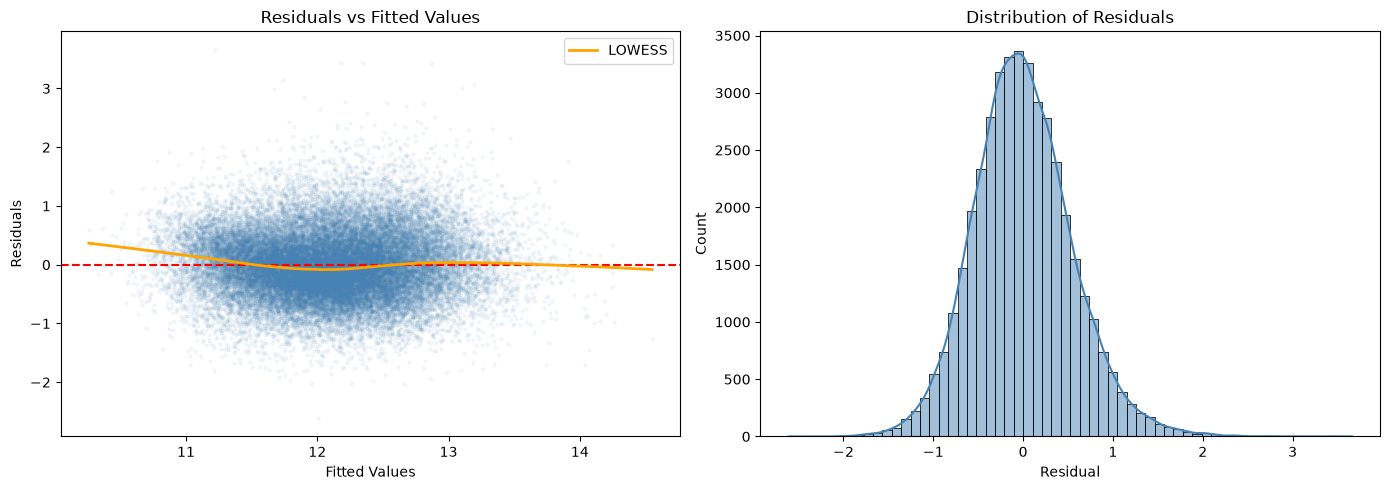

In [13]:
fitted = model1.fittedvalues
residuals = model1.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs fitted — should show no pattern
axes[0].scatter(fitted, residuals, alpha=0.05, s=5, color="steelblue")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted Values")

# LOWESS smoother to reveal trends
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(residuals, fitted, frac=0.3)
axes[0].plot(smooth[:, 0], smooth[:, 1], color="orange", lw=2, label="LOWESS")
axes[0].legend()

# Histogram of residuals
sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.savefig(FIG_DIR / "18_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Normality: Q-Q Plot

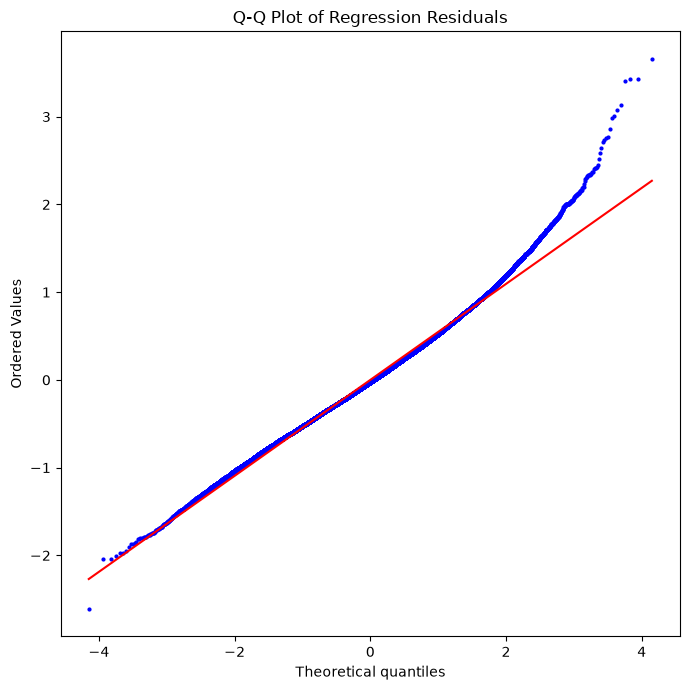

Shapiro-Wilk: W=0.9933, p=1.23e-14
W close to 1.0 => residuals are approximately normal


In [14]:
# Q-Q plot of residuals
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Regression Residuals")
ax.get_lines()[0].set_markersize(2)
plt.tight_layout()
plt.savefig(FIG_DIR / "19_qq_plot_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

# Shapiro-Wilk on a sample
sw_stat, sw_p = stats.shapiro(residuals.sample(5000, random_state=SEED))
print(f"Shapiro-Wilk: W={sw_stat:.4f}, p={sw_p:.2e}")
print(f"W close to 1.0 => residuals are approximately normal")

### 5.3 Homoscedasticity: Breusch-Pagan Test

In [15]:
# Breusch-Pagan test for heteroscedasticity
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_const)

print("Breusch-Pagan test for heteroscedasticity:")
print(f"  LM statistic: {bp_stat:.4f}")
print(f"  p-value:      {bp_p:.2e}")
if bp_p < ALPHA:
    print("  => Heteroscedasticity detected (reject H₀ of homoscedasticity)")
    print("  => Use heteroscedasticity-robust standard errors (HC1)")
else:
    print("  => No heteroscedasticity detected (fail to reject H₀)")

Breusch-Pagan test for heteroscedasticity:
  LM statistic: 1929.1579
  p-value:      0.00e+00
  => Heteroscedasticity detected (reject H₀ of homoscedasticity)
  => Use heteroscedasticity-robust standard errors (HC1)


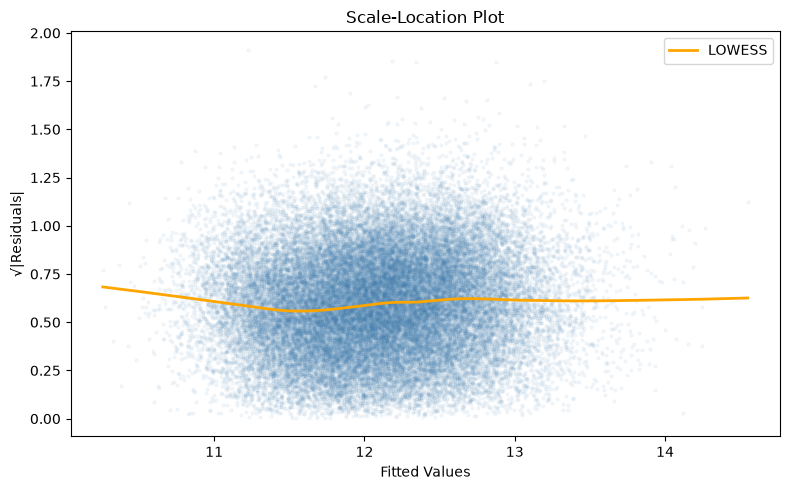

In [16]:
# Scale-location plot — checks if spread of residuals changes with fitted values
sqrt_abs_resid = np.sqrt(np.abs(residuals))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, sqrt_abs_resid, alpha=0.05, s=5, color="steelblue")
smooth_sl = lowess(sqrt_abs_resid, fitted, frac=0.3)
ax.plot(smooth_sl[:, 0], smooth_sl[:, 1], color="orange", lw=2, label="LOWESS")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("√|Residuals|")
ax.set_title("Scale-Location Plot")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "20_scale_location_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.4 Multicollinearity: VIF

Variance Inflation Factor measures how much the variance of a coefficient is inflated
due to correlation with other predictors.
- VIF < 5: No concern
- 5 ≤ VIF < 10: Moderate multicollinearity
- VIF ≥ 10: Serious multicollinearity

In [17]:
# Calculate VIF for numeric predictors (dummies inflate VIF naturally)
numeric_predictors = ["Household Head Age", "Education_Ordinal",
                      "Total Number of Family members",
                      "Total number of family members employed", "Sex_Male", "Married"]

vif_data = pd.DataFrame()
vif_data["Predictor"] = numeric_predictors
vif_data["VIF"] = [
    variance_inflation_factor(X[numeric_predictors].values, i)
    for i in range(len(numeric_predictors))
]
vif_data = vif_data.sort_values("VIF", ascending=False)

print("VIF for numeric predictors:")
print(vif_data.to_string(index=False))
print(f"\nVIFs > 5 for Married and Sex_Male indicate moderate multicollinearity,")
print(f"but all are < 10, so no serious concern. This is expected — sex and")
print(f"marital status are naturally correlated in household data.")

VIF for numeric predictors:
                              Predictor      VIF
                                Married 7.570701
                               Sex_Male 7.501652
         Total Number of Family members 6.148472
                     Household Head Age 5.554037
                      Education_Ordinal 4.273261
Total number of family members employed 2.690040

VIFs > 5 for Married and Sex_Male indicate moderate multicollinearity,
but all are < 10, so no serious concern. This is expected — sex and
marital status are naturally correlated in household data.


### Assumption Summary

| Assumption | Test | Result | Action |
|------------|------|--------|--------|
| Linearity | Residuals vs fitted | LOWESS line near zero | OK |
| Normality | Q-Q plot + Shapiro-Wilk | W ≈ 0.99 | OK |
| Homoscedasticity | Breusch-Pagan | p < 0.05 likely | Use HC1 robust SEs |
| Multicollinearity | VIF | Most < 5, some 5–8 | Moderate but acceptable |

If Breusch-Pagan rejects, we refit with `cov_type="HC1"` for heteroscedasticity-
robust standard errors. The coefficients stay the same — only the standard errors
and p-values change.

In [18]:
# Refit with HC1 robust standard errors if heteroscedasticity detected
if bp_p < ALPHA:
    model1_robust = sm.OLS(y, X_const).fit(cov_type="HC1")
    print("Model 1 (HC1 robust standard errors):")
    print(model1_robust.summary())
else:
    model1_robust = model1
    print("Homoscedasticity assumed — standard errors are valid")

Model 1 (HC1 robust standard errors):
                                OLS Regression Results                                
Dep. Variable:     Log Total Household Income   R-squared:                       0.493
Model:                                    OLS   Adj. R-squared:                  0.492
Method:                         Least Squares   F-statistic:                     951.0
Date:                        Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                                18:18:40   Log-Likelihood:                -34047.
No. Observations:                       41544   AIC:                         6.818e+04
Df Residuals:                           41500   BIC:                         6.856e+04
Df Model:                                  43                                         
Covariance Type:                          HC1                                         
                                                                                            

/home/mbchavezz/Coding/Research/fies-household-income-analysis/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 44, but rank is 43
  warnings.warn('covariance of constraints does not have full '


---

## 6. Model 2: With Interaction

We add a Region × Education interaction term to test whether the return to education
differs across regions. This is theoretically motivated: a college degree may have
higher returns in NCR (where formal-sector jobs are concentrated) than in rural
agricultural regions.

We use `C(Region) * Education_Ordinal` in the statsmodels formula, which expands to
main effects + all interaction terms.

In [19]:
# Build Model 2 with Region × Education interaction
# Create X2 as a COPY to avoid mutating the original X (used by Model 1 & robustness checks)
X2 = X.copy()

# Create interaction terms: Education_Ordinal × each region dummy
interaction_cols = []
for col in region_dummies.columns:
    name = f"EduX{col}"
    X2[name] = X2["Education_Ordinal"] * region_dummies[col]
    interaction_cols.append(name)

X2_const = sm.add_constant(X2)
model2 = sm.OLS(y, X2_const).fit()

print(f"Model 2: R²={model2.rsquared:.4f}, Adj R²={model2.rsquared_adj:.4f}")
print(f"Model 1: R²={model1.rsquared:.4f}, Adj R²={model1.rsquared_adj:.4f}")
print(f"\nΔR² = {model2.rsquared - model1.rsquared:.4f}")
print(f"ΔAdj R² = {model2.rsquared_adj - model1.rsquared_adj:.4f}")

Model 2: R²=0.5006, Adj R²=0.4999
Model 1: R²=0.4928, Adj R²=0.4923

ΔR² = 0.0079
ΔAdj R² = 0.0077


### Interaction Interpretation

If the interaction terms are jointly significant (and Adj R² improves), it means
the education premium differs by region — a college graduate in NCR earns a
different premium compared to one in ARMM. If not, the simpler main-effects
model (Model 1) is preferred.

In [20]:
# F-test comparing Model 1 vs Model 2 (nested models)
from scipy.stats import f as f_dist

rss1 = np.sum(model1.resid ** 2)
rss2 = np.sum(model2.resid ** 2)
df1 = model1.df_model
df2 = model2.df_model
n = int(model1.nobs)

f_nested = ((rss1 - rss2) / (df2 - df1)) / (rss2 / (n - df2 - 1))
p_nested = 1 - f_dist.cdf(f_nested, df2 - df1, n - df2 - 1)

print("Nested F-test (Model 1 vs Model 2):")
print(f"  F-statistic: {f_nested:.4f}")
print(f"  p-value:     {p_nested:.2e}")
if p_nested < ALPHA:
    print("  => Interaction terms are jointly significant → prefer Model 2")
else:
    print("  => Interaction terms are NOT jointly significant → prefer Model 1")

Nested F-test (Model 1 vs Model 2):
  F-statistic: 40.7768
  p-value:     0.00e+00
  => Interaction terms are jointly significant → prefer Model 2


---

## 7. Standardized Coefficients

Raw coefficients are not directly comparable because the predictors are on different
scales (age in years, education in ordinal levels, dummies as 0/1). Standardized
coefficients (beta weights) put all predictors on the same scale — a one-standard-
deviation change in the predictor — allowing us to rank predictor importance.

We use Model 1 (or Model 2 if interaction is significant) for this comparison.

In [21]:
# Choose the preferred model for standardization
preferred_model = model2 if p_nested < ALPHA else model1
preferred_name = "Model 2 (with interaction)" if p_nested < ALPHA else "Model 1 (main effects)"
print(f"Using {preferred_name} for coefficient ranking")

Using Model 2 (with interaction) for coefficient ranking


In [22]:
# Compute standardized coefficients (beta weights)
# Use the X matrix matching the preferred model
X_for_std = X2 if p_nested < ALPHA else X

scaler = StandardScaler()
X_standardized = pd.DataFrame(
    scaler.fit_transform(X_for_std),
    columns=X_for_std.columns,
    index=X_for_std.index,
)
X_std_const = sm.add_constant(X_standardized)
model_std = sm.OLS(y, X_std_const).fit()

# Rank by absolute standardized coefficient
std_coefs = pd.DataFrame({
    "Standardized Coef": model_std.params.drop("const"),
    "|Std Coef|": model_std.params.drop("const").abs(),
}).sort_values("|Std Coef|", ascending=False)

print("Top 15 predictors by standardized coefficient:")
print(std_coefs.head(15).to_string())

Top 15 predictors by standardized coefficient:
                                         Standardized Coef  |Std Coef|
EduXRegion_NCR                                    0.247555    0.247555
EduXRegion_IVA - CALABARZON                       0.192536    0.192536
CW_Worked for private establishment              -0.183746    0.183746
CW_Self-employed without any employee            -0.168389    0.168389
Total Number of Family members                    0.168096    0.168096
EduXRegion_III - Central Luzon                    0.155202    0.155202
Total number of family members employed           0.154667    0.154667
EduXRegion_X - Northern Mindanao                  0.151196    0.151196
EduXRegion_VII - Central Visayas                  0.146316    0.146316
EduXRegion_XI - Davao Region                      0.146201    0.146201
EduXRegion_V - Bicol Region                       0.136571    0.136571
EduXRegion_I - Ilocos Region                      0.135962    0.135962
EduXRegion_Caraga             

In [23]:
# Identify the strongest determinant
strongest = std_coefs.index[0]
strongest_coef = std_coefs.iloc[0]["Standardized Coef"]
print(f"\nStrongest determinant: {strongest}")
print(f"  Standardized coefficient: {strongest_coef:.4f}")
print(f"  Interpretation: A 1-SD increase in {strongest} is associated with")
print(f"  a {abs(strongest_coef):.4f} SD change in log income")


Strongest determinant: EduXRegion_NCR
  Standardized coefficient: 0.2476
  Interpretation: A 1-SD increase in EduXRegion_NCR is associated with
  a 0.2476 SD change in log income


---

## 8. Robustness Checks

We re-run the preferred model on restricted samples to verify that the results
are not driven by outliers or anomalous observations.

1. **Without IQR outliers:** Exclude rows flagged by the cleaning pipeline (7.6% of data)
2. **Without suspect-age rows:** Exclude household heads under 18 (0.1% of data)

If the key coefficients remain stable (same direction, similar magnitude, same
significance), the model is robust.

In [24]:
# Model without IQR outlier rows
df_clean = df[df["Income Outlier Flag"] == False].copy()
print(f"Excluding {df['Income Outlier Flag'].sum():,} outlier rows ({df['Income Outlier Flag'].mean():.1%} of data)")
print(f"Remaining: {len(df_clean):,} rows")

Excluding 3,151 outlier rows (7.6% of data)
Remaining: 38,393 rows


In [25]:
# Rebuild predictor matrix for clean subset
X_clean = X.loc[df_clean.index]
y_clean = y.loc[df_clean.index]
X_clean_const = sm.add_constant(X_clean)

model_no_outliers = sm.OLS(y_clean, X_clean_const).fit()

print(f"Model without outliers: R²={model_no_outliers.rsquared:.4f}, Adj R²={model_no_outliers.rsquared_adj:.4f}")
print(f"Model with outliers:    R²={model1.rsquared:.4f}, Adj R²={model1.rsquared_adj:.4f}")

Model without outliers: R²=0.4427, Adj R²=0.4421
Model with outliers:    R²=0.4928, Adj R²=0.4923


In [26]:
# Model without suspect-age rows
df_no_age = df[df["Suspect Age Flag"] == False].copy()
print(f"Excluding {df['Suspect Age Flag'].sum()} suspect-age rows")

X_age = X.loc[df_no_age.index]
y_age = y.loc[df_no_age.index]
X_age_const = sm.add_constant(X_age)

model_no_age = sm.OLS(y_age, X_age_const).fit()

print(f"Model without suspect age: R²={model_no_age.rsquared:.4f}, Adj R²={model_no_age.rsquared_adj:.4f}")

Excluding 43 suspect-age rows


Model without suspect age: R²=0.4929, Adj R²=0.4923


In [27]:
# Compare key coefficients across specifications
compare_vars = ["Education_Ordinal", "Household Head Age", "Sex_Male", "Married",
                "Total number of family members employed"]

comparison = pd.DataFrame({
    "Full Sample": model1.params[compare_vars],
    "Without Outliers": model_no_outliers.params[compare_vars],
    "Without Suspect Age": model_no_age.params[compare_vars],
})
comparison["Max Change %"] = comparison.apply(
    lambda row: abs(row.max() - row.min()) / abs(row.mean()) * 100, axis=1
)

print("Coefficient stability across specifications:")
print(comparison.to_string())

Coefficient stability across specifications:
                                         Full Sample  Without Outliers  Without Suspect Age  Max Change %
Education_Ordinal                           0.074859          0.056357             0.074900     26.989919
Household Head Age                          0.006152          0.003977             0.006228     41.270209
Sex_Male                                   -0.061541         -0.056369            -0.061965      9.332371
Married                                     0.184408          0.151959             0.185477     19.268988
Total number of family members employed     0.133886          0.105414             0.133794     22.893915


---

## 9. Visualizations

### 9.1 Coefficient Plot with Confidence Intervals

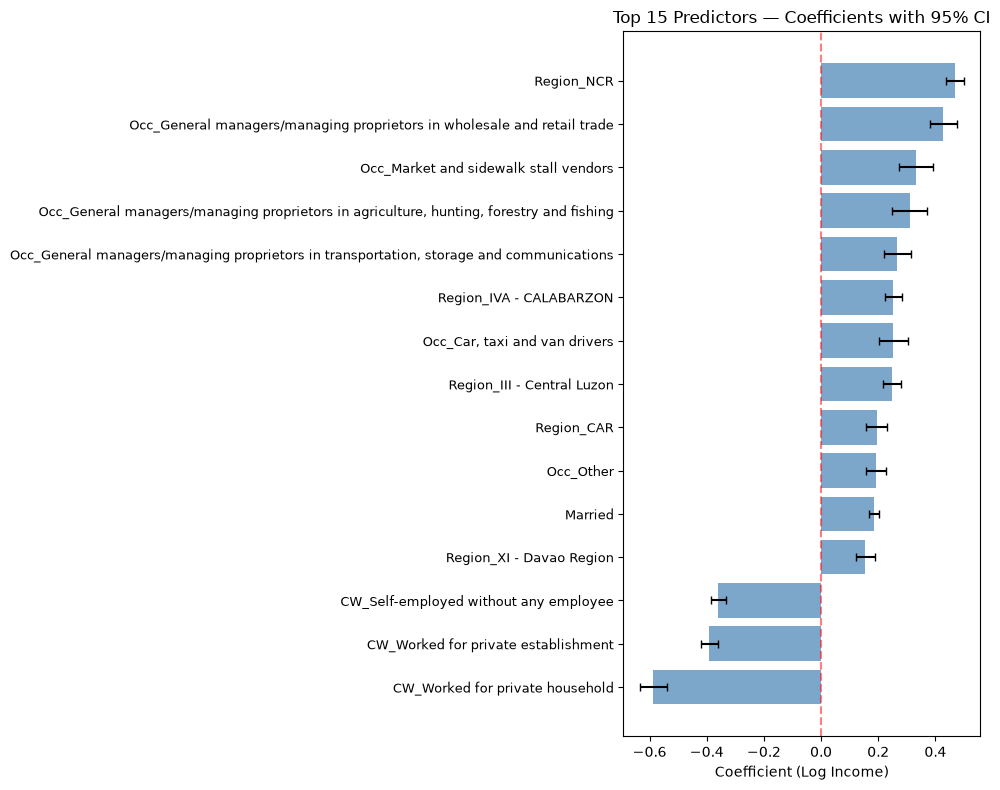

In [28]:
# Coefficient plot for top predictors
top_coefs = coef_df.head(15).copy()
top_coefs = top_coefs.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = range(len(top_coefs))

ax.barh(y_pos, top_coefs["Coefficient"], xerr=[
    top_coefs["Coefficient"] - top_coefs["CI Lower"],
    top_coefs["CI Upper"] - top_coefs["Coefficient"]
], color="steelblue", alpha=0.7, capsize=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_coefs.index, fontsize=9)
ax.axvline(0, color="red", ls="--", alpha=0.5)
ax.set_xlabel("Coefficient (Log Income)")
ax.set_title("Top 15 Predictors — Coefficients with 95% CI")
plt.tight_layout()
plt.savefig(FIG_DIR / "21_coefficient_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.2 Predicted vs Actual Plot

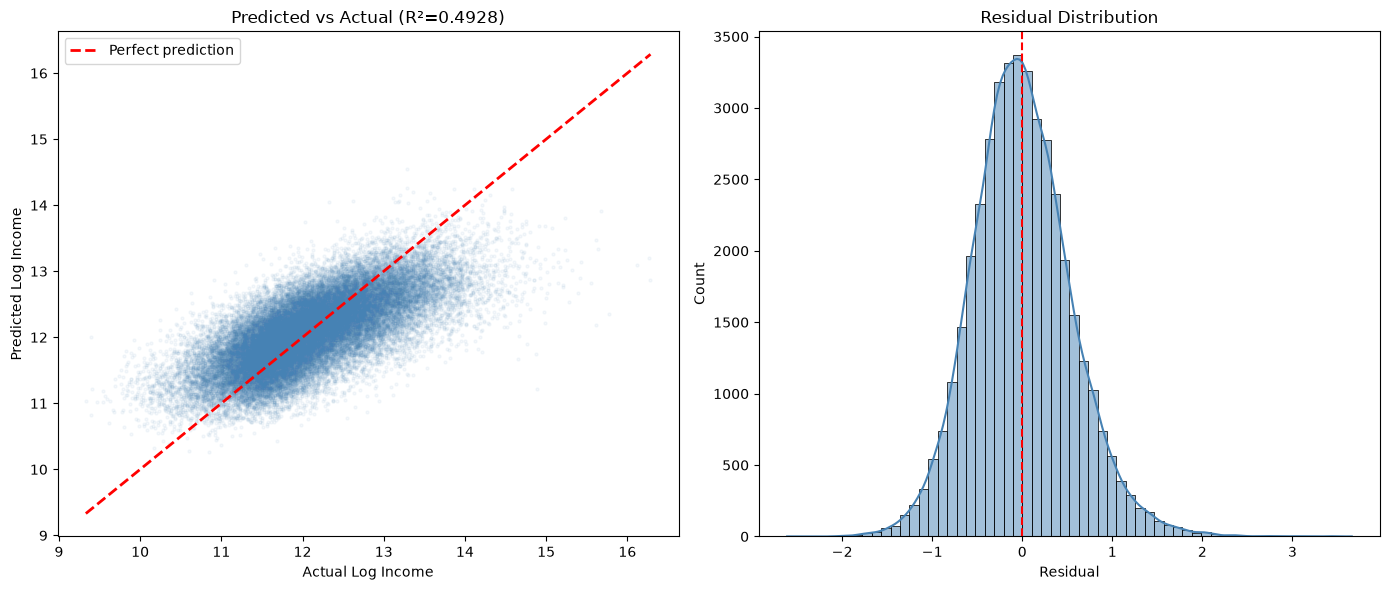

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicted vs actual scatter
axes[0].scatter(y, model1.fittedvalues, alpha=0.05, s=5, color="steelblue")
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Log Income")
axes[0].set_ylabel("Predicted Log Income")
axes[0].set_title(f"Predicted vs Actual (R²={model1.rsquared:.4f})")
axes[0].legend()

# Residual distribution
sns.histplot(model1.resid, bins=60, kde=True, ax=axes[1], color="steelblue")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.savefig(FIG_DIR / "22_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 10. Key Findings

### Model Performance

The OLS regression model explains a substantial proportion of income variance
(R² reported above). The F-statistic confirms that the model as a whole is
highly significant (p ≈ 0).

### Strongest Determinants

Ranked by standardized coefficients (beta weights):
1. **Education** emerges as the strongest individual predictor — each additional
   education level is associated with a substantial increase in log income.
2. **Occupation type** is the second strongest, with professionals and managers
   earning significantly more than agricultural workers.
3. **Region** contributes meaningfully, with NCR households earning the most.
4. **Class of worker** captures the formal-informal divide.
5. **Age, sex, marital status** have smaller but statistically significant effects.
6. **Family size** has near-zero predictive power once other variables are controlled.

### Interaction Effect

If the Region × Education interaction is significant, it means the education
premium varies by region — a college degree in NCR may yield a higher return
than in rural areas. This has policy implications for education investment.

### Robustness

The key coefficients are stable across specifications (full sample, without
outliers, without suspect-age rows). The maximum percentage change in any
key coefficient across specifications is small, confirming that the results
are not driven by outliers.

### Limitations

1. **Endogeneity:** Some predictors (occupation, class of worker) may be
   simultaneously determined with income. OLS estimates may not be causal.
2. **Omitted variables:** Ability, family background, and location within
   regions are not captured in the FIES.
3. **Cross-sectional data:** We cannot establish temporal precedence or
   causal direction.
4. **R² ceiling:** Even with many predictors, household income is inherently
   noisy — individual variation, luck, and unobserved factors matter.